In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
import timm
from PIL import Image
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device('cuda')
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"Free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1024**3:.1f}GB")

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

CLASSES    = config['classes']
IMAGE_SIZE = config['image_size']
test_df    = config['test_df']
SEG_DIR    = '../data/segmented_images'

os.makedirs('../results/gradcam', exist_ok=True)

print(f"Classes : {len(CLASSES)}")
print(f"Test    : {len(test_df):,}")
print("✅ Setup done!")

/home/lhotse1/student/btech2023/achanta/miniconda3/envs/cv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU  : Tesla V100-PCIE-32GB
Free : 31.7GB
Classes : 15
Test    : 22,424
✅ Setup done!


In [2]:
# Load all 6 trained models
models = {}

# 1. ResNet50
resnet = timm.create_model('resnet50', pretrained=False, num_classes=len(CLASSES))
resnet.load_state_dict(torch.load('../checkpoints/ResNet50/best.pt',
                       map_location=device, weights_only=False)['model_state'])
resnet = resnet.to(device).eval()
models['ResNet50'] = resnet
print("✅ ResNet50 loaded!")

# 2. DenseNet121
densenet = timm.create_model('densenet121', pretrained=False, num_classes=len(CLASSES))
densenet.load_state_dict(torch.load('../checkpoints/DenseNet121/best.pt',
                         map_location=device, weights_only=False)['model_state'])
densenet = densenet.to(device).eval()
models['DenseNet121'] = densenet
print("✅ DenseNet121 loaded!")

# 3. EfficientNet
efficientnet = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(CLASSES))
efficientnet.load_state_dict(torch.load('../checkpoints/EfficientNet-B0/best.pt',
                             map_location=device, weights_only=False)['model_state'])
efficientnet = efficientnet.to(device).eval()
models['EfficientNet'] = efficientnet
print("✅ EfficientNet loaded!")

# 4. VGG16
vgg = timm.create_model('vgg16', pretrained=False, num_classes=len(CLASSES))
vgg.load_state_dict(torch.load('../checkpoints/VGG-16/best.pt',
                    map_location=device, weights_only=False)['model_state'])
vgg = vgg.to(device).eval()
models['VGG16'] = vgg
print("✅ VGG16 loaded!")

# 5. ViT
vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(CLASSES))
vit.load_state_dict(torch.load('../checkpoints/ViT/best.pt',
                    map_location=device, weights_only=False)['model_state'])
vit = vit.to(device).eval()
models['ViT'] = vit
print("✅ ViT loaded!")

# 6. ConvNeXt
convnext = timm.create_model('convnext_base', pretrained=False, num_classes=len(CLASSES))
convnext.load_state_dict(torch.load('../checkpoints/ConvNeXt/best.pt',
                         map_location=device, weights_only=False)['model_state'])
convnext = convnext.to(device).eval()
models['ConvNeXt'] = convnext
print("✅ ConvNeXt loaded!")

print(f"\n✅ All {len(models)} models loaded!")

✅ ResNet50 loaded!
✅ DenseNet121 loaded!
✅ EfficientNet loaded!
✅ VGG16 loaded!
✅ ViT loaded!
✅ ConvNeXt loaded!

✅ All 6 models loaded!


In [3]:
# GradCAM needs the last convolutional layer to hook into for each architecture
target_layers = {
    'ResNet50':     [models['ResNet50'].layer4[-1]],
    'DenseNet121':  [models['DenseNet121'].features.denseblock4],
    'EfficientNet': [models['EfficientNet'].conv_head],
    'VGG16':        [models['VGG16'].features[-1]],
    'ConvNeXt':     [models['ConvNeXt'].stages[-1].blocks[-1]],
}
# ViT is excluded here — GradCAM doesn't work cleanly on transformers,
# it needs Attention Rollout instead (that's notebook 04c)

print("✅ Target layers defined for 5 CNN-based models!")
print("   (ViT will be handled separately in 04c_attention_rollout.ipynb)")

✅ Target layers defined for 5 CNN-based models!
   (ViT will be handled separately in 04c_attention_rollout.ipynb)


In [6]:
# The raw test_df only has 'Finding Labels' as a pipe-separated string
# e.g. "Infiltration|Mass|Nodule" — need to expand into one column per class

for c in CLASSES:
    if c not in test_df.columns:
        test_df[c] = test_df['Finding Labels'].apply(
            lambda x: 1 if c in str(x).split('|') else 0
        )

print("✅ One-hot encoded columns added!")
print(test_df[CLASSES].sum().sort_values(ascending=False))

# Now pick samples that have at least one real disease (exclude "No Finding")
disease_classes = [c for c in CLASSES if c != 'No Finding']
sample_df = test_df[test_df[disease_classes].sum(axis=1) > 0].sample(6, random_state=42)
sample_files = sample_df['Image Index'].tolist()

print("\nSample images selected:")
for f in sample_files:
    row = sample_df[sample_df['Image Index'] == f].iloc[0]
    positive_classes = [c for c in disease_classes if row[c] == 1]
    print(f"  {f} → {positive_classes}")

✅ One-hot encoded columns added!
No Finding            12169
Infiltration           3943
Effusion               2623
Atelectasis            2223
Nodule                 1282
Mass                   1133
Pneumothorax           1045
Consolidation           894
Pleural_Thickening      663
Cardiomegaly            555
Emphysema               487
Edema                   446
Fibrosis                319
Pneumonia               277
Hernia                   46
dtype: int64

Sample images selected:
  00003868_007.png → ['Atelectasis']
  00026683_008.png → ['Pneumothorax']
  00012687_004.png → ['Pneumothorax', 'Emphysema']
  00028431_002.png → ['Consolidation']
  00003989_021.png → ['Cardiomegaly']
  00021976_011.png → ['Pneumothorax']


In [5]:
print("test_df columns:")
print(test_df.columns.tolist())
print()
print(test_df.head(3))

test_df columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

            Image Index            Finding Labels  Follow-up #  Patient ID  \
89645  00022260_003.png                No Finding            3       22260   
47446  00012048_007.png  Infiltration|Mass|Nodule            7       12048   
57963  00014352_005.png                No Finding            5       14352   

      Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
89645        054Y              F            PA                 2542     2434   
47446        065Y              M            AP                 2500     2048   
57963        006Y              M            PA                 2992     2033   

       OriginalImagePixelSpacing[x     y]  Unnamed: 11  
89645                        0.143  0.143          NaN  
47446                        0.168 

In [7]:
print(f"Total test images: {len(test_df):,}")
print(f"Images with 'No Finding': {(test_df['No Finding']==1).sum():,}" if 'No Finding' in CLASSES else "")

Total test images: 22,424
Images with 'No Finding': 12,169


In [8]:
def load_and_preprocess(fname):
    img_path = os.path.join(SEG_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    rgb_img = np.array(img.resize((IMAGE_SIZE, IMAGE_SIZE))).astype(np.float32) / 255.0
    tensor = val_transform(img).unsqueeze(0).to(device)
    return rgb_img, tensor

gradcam_results = {}

for fname in sample_files:
    rgb_img, input_tensor = load_and_preprocess(fname)
    gradcam_results[fname] = {'original': rgb_img}

    # Use the actual ground-truth disease label as the CAM target
    row = sample_df[sample_df['Image Index'] == fname].iloc[0]
    gt_class_name = [c for c in disease_classes if row[c] == 1][0]  # first true label
    gt_class_idx = CLASSES.index(gt_class_name)

    for model_name in target_layers:
        model = models[model_name]
        cam = GradCAM(model=model, target_layers=target_layers[model_name])

        with torch.no_grad():
            output = model(input_tensor)
            pred_prob = torch.sigmoid(output)[0, gt_class_idx].item()

        targets = [ClassifierOutputTarget(gt_class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        gradcam_results[fname][model_name] = {
            'cam_image': cam_image,
            'target_class': gt_class_name,
            'pred_prob': pred_prob
        }

    print(f"✅ GradCAM done for {fname} (target: {gt_class_name})")

print(f"\n✅ GradCAM computed for all {len(sample_files)} images × {len(target_layers)} models!")

✅ GradCAM done for 00003868_007.png (target: Atelectasis)
✅ GradCAM done for 00026683_008.png (target: Pneumothorax)
✅ GradCAM done for 00012687_004.png (target: Pneumothorax)
✅ GradCAM done for 00028431_002.png (target: Consolidation)
✅ GradCAM done for 00003989_021.png (target: Cardiomegaly)
✅ GradCAM done for 00021976_011.png (target: Pneumothorax)

✅ GradCAM computed for all 6 images × 5 models!


In [10]:
import pandas as pd

bbox_path = '../data/NIH/BBox_List_2017_Official_NIH.csv'
bbox_df = pd.read_csv(bbox_path)

print(bbox_df.columns.tolist())
print(bbox_df.head())
print(f"\nTotal bbox annotations: {len(bbox_df)}")
print(f"Unique images: {bbox_df['Image Index'].nunique()}")

# Column name for finding label varies across NIH releases — check both common variants
label_col = 'Finding Label' if 'Finding Label' in bbox_df.columns else 'Finding Labels'
print(f"\nClasses covered:\n{bbox_df[label_col].value_counts()}")

['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']
        Image Index Finding Label     Bbox [x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

           h]  Unnamed: 6  Unnamed: 7  Unnamed: 8  
0   79.186441         NaN         NaN         NaN  
1  313.491525         NaN         NaN         NaN  
2  216.949153         NaN         NaN         NaN  
3   55.322034         NaN         NaN         NaN  
4   78.101695         NaN         NaN         NaN  

Total bbox annotations: 984
Unique images: 880

Classes covered:
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltr

In [11]:
# Fix the awkward column names from the CSV split
bbox_df = bbox_df.rename(columns={
    'Bbox [x': 'x',
    'y': 'y',
    'w': 'w',
    'h]': 'h'
})
bbox_df = bbox_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

# Fix label naming mismatch between bbox file and CLASSES
label_map = {'Infiltrate': 'Infiltration'}
bbox_df['Finding Label'] = bbox_df['Finding Label'].replace(label_map)

# Keep only rows whose label exists in our CLASSES list
bbox_df = bbox_df[bbox_df['Finding Label'].isin(CLASSES)].reset_index(drop=True)

print(f"✅ Cleaned bbox_df: {len(bbox_df)} annotations across {bbox_df['Image Index'].nunique()} images")
print(bbox_df['Finding Label'].value_counts())

✅ Cleaned bbox_df: 984 annotations across 880 images
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltration    123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64


In [15]:
ORIGINAL_RES = 1024  # NIH ChestX-ray14 standard annotation resolution
scale = IMAGE_SIZE / ORIGINAL_RES

bbox_df['x_scaled'] = bbox_df['x'] * scale
bbox_df['y_scaled'] = bbox_df['y'] * scale
bbox_df['w_scaled'] = bbox_df['w'] * scale
bbox_df['h_scaled'] = bbox_df['h'] * scale

print(f"Scale factor: {scale:.4f}")
print(bbox_df[['Image Index','Finding Label','x','y','w','h','x_scaled','y_scaled','w_scaled','h_scaled']].head())

Scale factor: 0.2188
        Image Index Finding Label           x           y           w  \
0  00013118_008.png   Atelectasis  225.084746  547.019217   86.779661   
1  00014716_007.png   Atelectasis  686.101695  131.543498  185.491525   
2  00029817_009.png   Atelectasis  221.830508  317.053115  155.118644   
3  00014687_001.png   Atelectasis  726.237288  494.951420  141.016949   
4  00017877_001.png   Atelectasis  660.067797  569.780787  200.677966   

            h    x_scaled    y_scaled   w_scaled   h_scaled  
0   79.186441   49.237288  119.660454  18.983051  17.322034  
1  313.491525  150.084746   28.775140  40.576271  68.576271  
2  216.949153   48.525424   69.355369  33.932203  47.457627  
3   55.322034  158.864407  108.270623  30.847458  12.101695  
4   78.101695  144.389831  124.639547  43.898305  17.084746  


In [17]:
# Check whether bbox images exist in your segmented set
missing = []
for fname in bbox_df['Image Index'].unique():
    path = os.path.join(SEG_DIR, fname)
    if not os.path.exists(path):
        missing.append(fname)

print(f"Total bbox images: {bbox_df['Image Index'].nunique()}")
print(f"Found in {SEG_DIR}: {bbox_df['Image Index'].nunique() - len(missing)}")
print(f"Missing: {len(missing)}")
if missing[:5]:
    print("Example missing:", missing[:5])

Total bbox images: 880
Found in ../data/segmented_images: 880
Missing: 0


In [18]:
def cam_to_bbox_mask(grayscale_cam, threshold=0.5):
    """Convert a GradCAM heatmap into a binary mask by thresholding activation."""
    return (grayscale_cam >= threshold).astype(np.uint8)

def gt_bbox_to_mask(x, y, w, h, img_size):
    """Convert a scaled bounding box (x,y,w,h) into a binary mask of shape (img_size, img_size)."""
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    x1, y1 = int(round(x)), int(round(y))
    x2, y2 = int(round(x + w)), int(round(y + h))
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_size, x2), min(img_size, y2)
    mask[y1:y2, x1:x2] = 1
    return mask

def compute_iou(mask1, mask2):
    """IoU between two binary masks."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [20]:
from tqdm import tqdm

In [21]:
iou_results = {model_name: [] for model_name in target_layers}
detailed_records = []

# Instantiate one CAM object per model (reused across images — faster than recreating each time)
cam_objects = {
    model_name: GradCAM(model=models[model_name], target_layers=target_layers[model_name])
    for model_name in target_layers
}

for idx, row in tqdm(bbox_df.iterrows(), total=len(bbox_df), desc="GradCAM + IoU"):
    fname = row['Image Index']
    gt_label = row['Finding Label']

    if gt_label not in CLASSES:
        continue
    gt_class_idx = CLASSES.index(gt_label)

    img_path = os.path.join(SEG_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(img).unsqueeze(0).to(device)

    gt_mask = gt_bbox_to_mask(row['x_scaled'], row['y_scaled'],
                               row['w_scaled'], row['h_scaled'], IMAGE_SIZE)

    for model_name, cam in cam_objects.items():
        targets = [ClassifierOutputTarget(gt_class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_mask = cam_to_bbox_mask(grayscale_cam, threshold=0.5)

        iou = compute_iou(cam_mask, gt_mask)
        iou_results[model_name].append(iou)

        detailed_records.append({
            'Image Index': fname,
            'Finding Label': gt_label,
            'Model': model_name,
            'IoU': iou
        })

print("\n✅ GradCAM + IoU computed for all images and models!")

GradCAM + IoU: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 984/984 [04:15<00:00,  3.86it/s]


✅ GradCAM + IoU computed for all images and models!


In [22]:
print("="*60)
print("  GradCAM vs Ground-Truth BBox — Mean IoU per Model")
print("="*60)

summary = {}
for model_name, ious in iou_results.items():
    mean_iou = np.mean(ious)
    summary[model_name] = round(mean_iou, 4)
    print(f"{model_name:15s} → Mean IoU: {mean_iou:.4f}  (n={len(ious)})")

best_model = max(summary, key=summary.get)
print("="*60)
print(f"🏆 Best explainability alignment: {best_model} (IoU={summary[best_model]:.4f})")

# Per-disease breakdown
iou_df = pd.DataFrame(detailed_records)
print("\nMean IoU by disease class and model:")
pivot = iou_df.pivot_table(index='Finding Label', columns='Model', values='IoU', aggfunc='mean')
print(pivot.round(3))

  GradCAM vs Ground-Truth BBox — Mean IoU per Model
ResNet50        → Mean IoU: 0.0527  (n=984)
DenseNet121     → Mean IoU: 0.1441  (n=984)
EfficientNet    → Mean IoU: 0.0387  (n=984)
VGG16           → Mean IoU: 0.1216  (n=984)
ConvNeXt        → Mean IoU: 0.1525  (n=984)
🏆 Best explainability alignment: ConvNeXt (IoU=0.1525)

Mean IoU by disease class and model:
Model          ConvNeXt  DenseNet121  EfficientNet  ResNet50  VGG16
Finding Label                                                      
Atelectasis       0.135        0.074         0.042     0.040  0.064
Cardiomegaly      0.215        0.364         0.062     0.072  0.193
Effusion          0.124        0.152         0.061     0.091  0.213
Infiltration      0.148        0.134         0.051     0.065  0.128
Mass              0.222        0.120         0.017     0.062  0.175
Nodule            0.067        0.021         0.002     0.016  0.029
Pneumonia         0.204        0.079         0.021     0.020  0.043
Pneumothorax      0.086

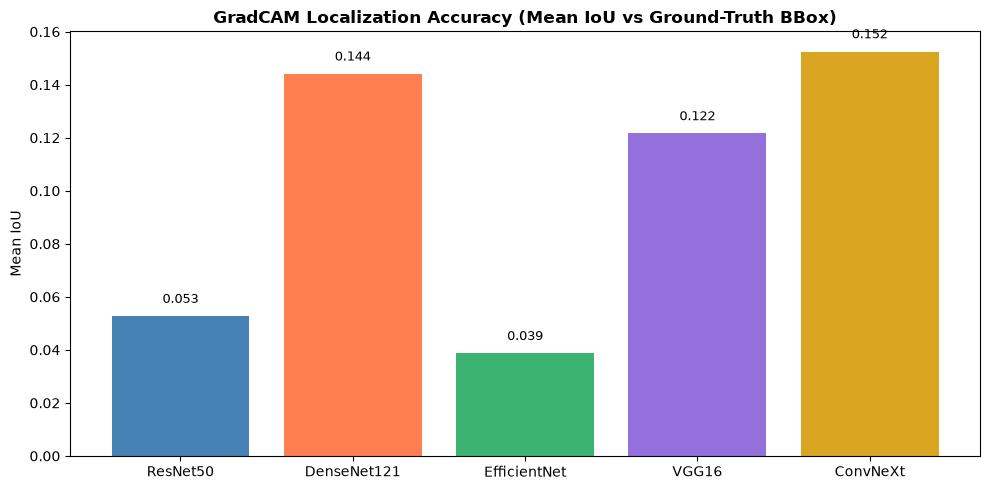

✅ gradcam_iou_results.pkl saved!
👉 Next: 04b_gradcam_plus.ipynb (same pipeline, GradCAMPlusPlus)


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(summary.keys())
values = list(summary.values())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']
ax.bar(names, values, color=colors)
ax.set_title('GradCAM Localization Accuracy (Mean IoU vs Ground-Truth BBox)', fontweight='bold')
ax.set_ylabel('Mean IoU')
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/gradcam/gradcam_iou_comparison.png', dpi=150)
plt.show()

with open('../data/gradcam_iou_results.pkl', 'wb') as f:
    pickle.dump({
        'summary': summary,
        'detailed_records': detailed_records,
        'iou_df': iou_df
    }, f)

print("✅ gradcam_iou_results.pkl saved!")
print("👉 Next: 04b_gradcam_plus.ipynb (same pipeline, GradCAMPlusPlus)")